# Conditioned Backtest 

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from   matplotlib.ticker import FuncFormatter

# Get Data

In [2]:
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(root_path, "data")
raw_path  = os.path.join(data_path, "RawData")
tsy_path  = os.path.join(raw_path, "TreasuryFutures.parquet")

process_path = os.path.join(data_path, "ProcessedData")
date_path    = os.path.join(process_path, "OrderedDates.parquet")

In [3]:
df_tsy   = pd.read_parquet(path = tsy_path, engine = "pyarrow")
df_dates = pd.read_parquet(path = date_path, engine = "pyarrow")

# Naive Strategy: Trading around FOMC Days

Start by plotting the cumulative basis points around FOMC days and then plaback the returns

In [4]:
df_tsy_prep = (df_tsy[
    ["date", "security", "PX_bps"]].
    assign(
        date     = lambda x: pd.to_datetime(x.date).dt.date,
        security = lambda x: x.security.str.split("1").str[0].str.strip()))

In [5]:
df_combined = (df_dates.merge(
    right = df_tsy_prep, how = "inner", on = ["date"]))

In [6]:
df_avg_rtn = (df_combined[
    ["day", "security", "PX_bps"]].
    groupby(["day", "security"]).
    agg("mean").
    reset_index().
    rename(columns = {"PX_bps": "avg_rtn"}))

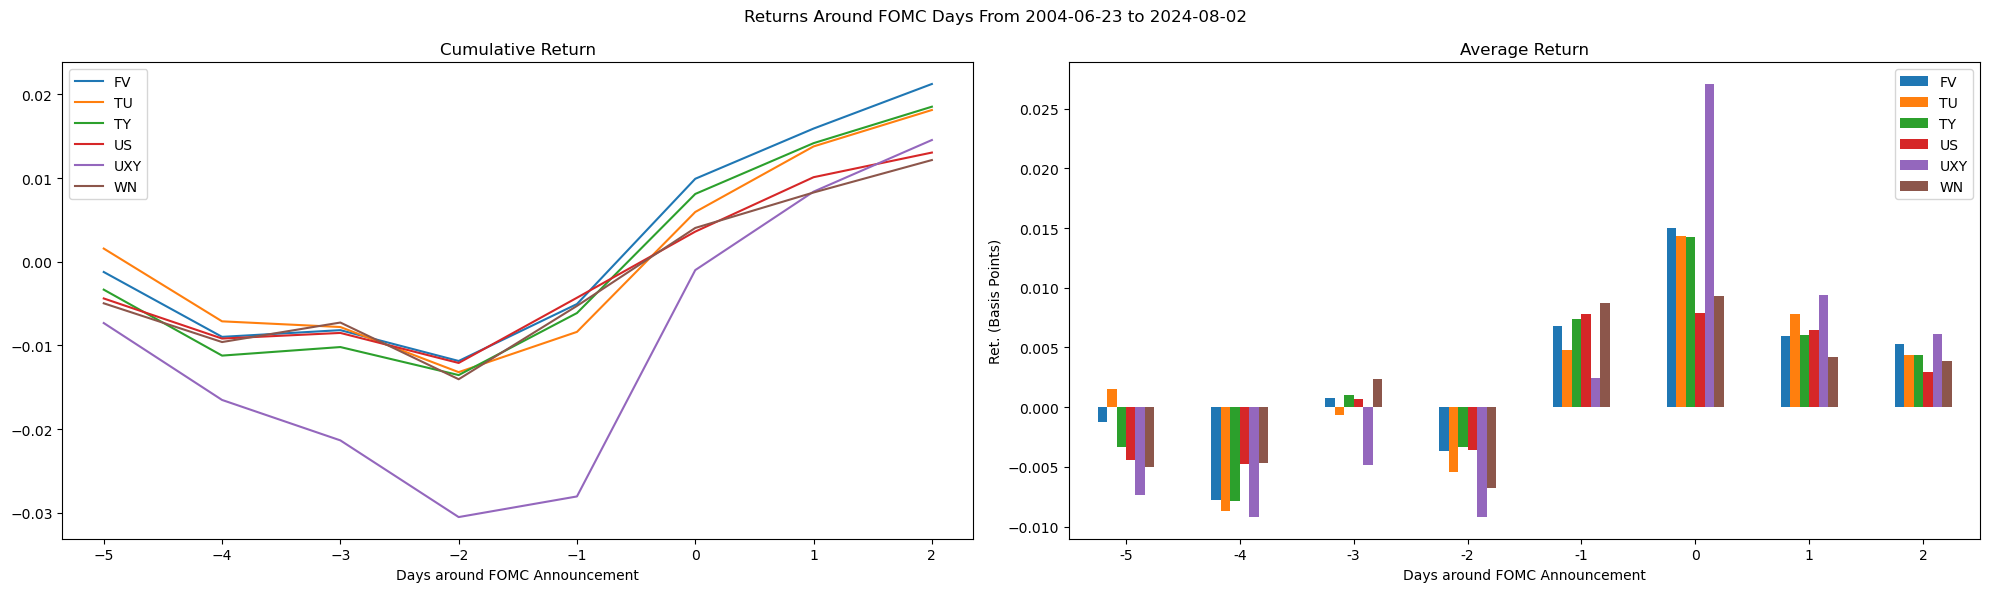

In [7]:
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

(df_combined.drop(
    columns = ["event", "date"]).
    groupby(["day", "security"]).
    agg("mean").
    reset_index().
    rename(columns = {"security": ""}).
    pivot(index = "day", columns = "", values = "PX_bps").
    cumsum().
    plot(
        xlabel = "Cuml. Ret. (Basis Points)",
        ax     = axes[0],
        title  = "Cumulative Return"))

(df_avg_rtn.rename(columns = {
    "security": ""}).
    pivot(index = "day", columns = "", values = "avg_rtn").
    plot(
        kind   = "bar",
        ax     = axes[1],
        rot    = 0,
        ylabel = "Ret. (Basis Points)",
        title  = "Average Return"))

for ax in axes.flatten():
    ax.set_xlabel("Days around FOMC Announcement")

fig.suptitle("Returns Around FOMC Days From {} to {}".format(
    df_combined.date.min(),
    df_combined.date.max()))
plt.tight_layout()

Based on the cumulative basis points graph above start with a simple playback strategy of shorting Treasury Futures 5 days before and then flipping long 2 days before FOMC announcement. 

In [8]:
df_naive_signal = (df_combined.groupby(
    ["date", "security"]).
    head(1).
    assign(signal_rtn = lambda x: np.where(x.day <= -2, -x.PX_bps, x.PX_bps)))

In [9]:
df_avg_signal = (df_combined.groupby(
    ["date", "security"]).
    head(1).
    merge(right = df_avg_rtn, how = "inner", on = ["day", "security"]).
    assign(signal_rtn = lambda x: np.sign(x.avg_rtn) * x.PX_bps))

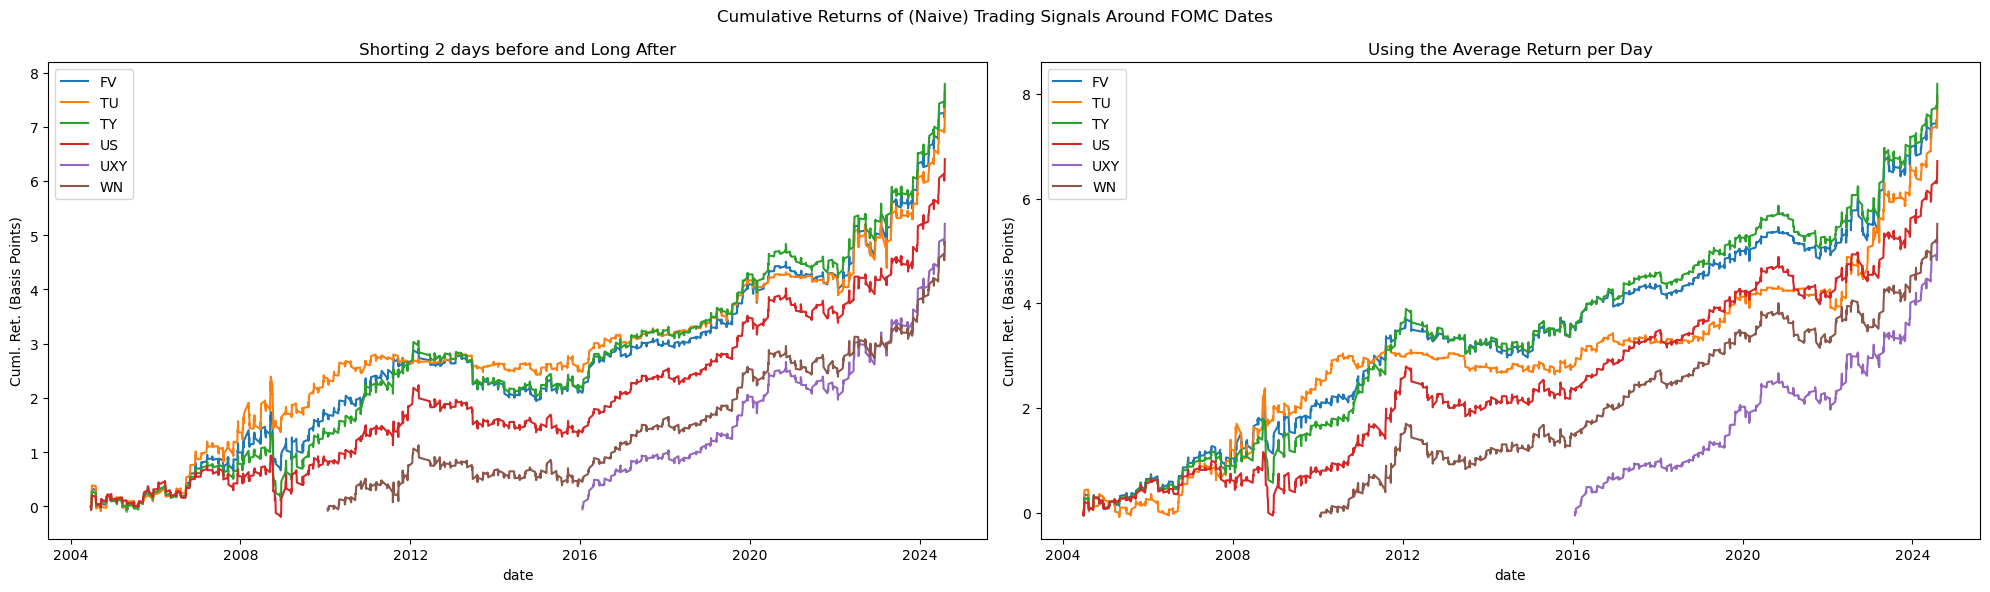

In [10]:
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

(df_naive_signal.
    rename(columns = {"security": ""}).
    pivot(index = "date", columns = "", values = "signal_rtn").
    cumsum().
    plot(
        ax    = axes[0],
        title = "Shorting 2 days before and Long After"))

(df_avg_signal.
    rename(columns = {"security": ""}).
    pivot(index = "date", columns = "", values = "signal_rtn").
    cumsum().
    plot(
        ax    = axes[1],
        title = "Using the Average Return per Day"))

for ax in axes.flatten():
    ax.set_ylabel("Cuml. Ret. (Basis Points)")

fig.suptitle("Cumulative Returns of (Naive) Trading Signals Around FOMC Dates")
plt.tight_layout()

In [11]:
df_combined_strat = (pd.concat([
    df_naive_signal.assign(name = "raw_val"),
    df_avg_signal.assign(name = "avg_val")]))

In [12]:
df_strat_sharpe = (df_combined_strat[
    ["signal_rtn", "security", "name"]].
    groupby(["security", "name"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index())

In [13]:
df_tmp_sharpe = (df_combined_strat[
    ["date", "security", "PX_bps"]].
    drop_duplicates().
    drop(columns = ["date"]).
    groupby("security").
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    rename(columns = {"PX_bps": "tmp_sharpe"}))

In [14]:
df_full_sharpe = (df_tsy[
    ["security", "PX_bps"]].
    assign(security = lambda x: x.security.str.split("1").str[0].str.strip()).
    groupby("security").
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    rename(columns = {"PX_bps": "full_sharpe"}))

In [15]:
(df_strat_sharpe.pivot(
    index = "security", columns = "name", values = "signal_rtn").
    merge(right = df_tmp_sharpe, how = "inner", on = ["security"]).
    merge(right = df_full_sharpe, how = "inner", on = ["security"]).
    T.
    assign(Avg = lambda x: x.mean(axis = 1)).
    T.
    rename(columns = {
        "avg_val"    : "Avg. Ret. Strat",
        "raw_val"    : "Naive Strat",
        "tmp_sharpe" : "Sharpe around FOMC",
        "full_sharpe": "Full Hist Sharpe"}).
    apply(lambda x: np.round(x,3)))

,Avg. Ret. Strat,Naive Strat,Sharpe around FOMC,Full Hist Sharpe
security,,,,
FV,1.623,1.557,0.775,0.304
TU,1.606,1.512,0.645,0.282
TY,1.708,1.623,0.701,0.279
US,1.548,1.474,0.574,0.166
UXY,2.750,2.750,0.519,-0.215
WN,1.799,1.587,0.540,0.045
Avg,1.839,1.751,0.626,0.144


Now run the average returns analysis out of sample, which is done by taking the rolling out of sample average and then applying it to the next FOMC announcement

In [16]:
df_oos = (df_combined.pivot(
    index = "event", columns = ["day", "security"], values = "PX_bps").
    expanding().
    mean().
    shift().
    reset_index().
    melt(id_vars = [("event", "")], value_name = "signal").
    rename(columns = {("event", ""): "event"}).
    merge(right = df_combined, how = "inner", on = ["event", "day", "security"]).
    assign(signal_rtn = lambda x: np.sign(x.signal) * x.PX_bps))

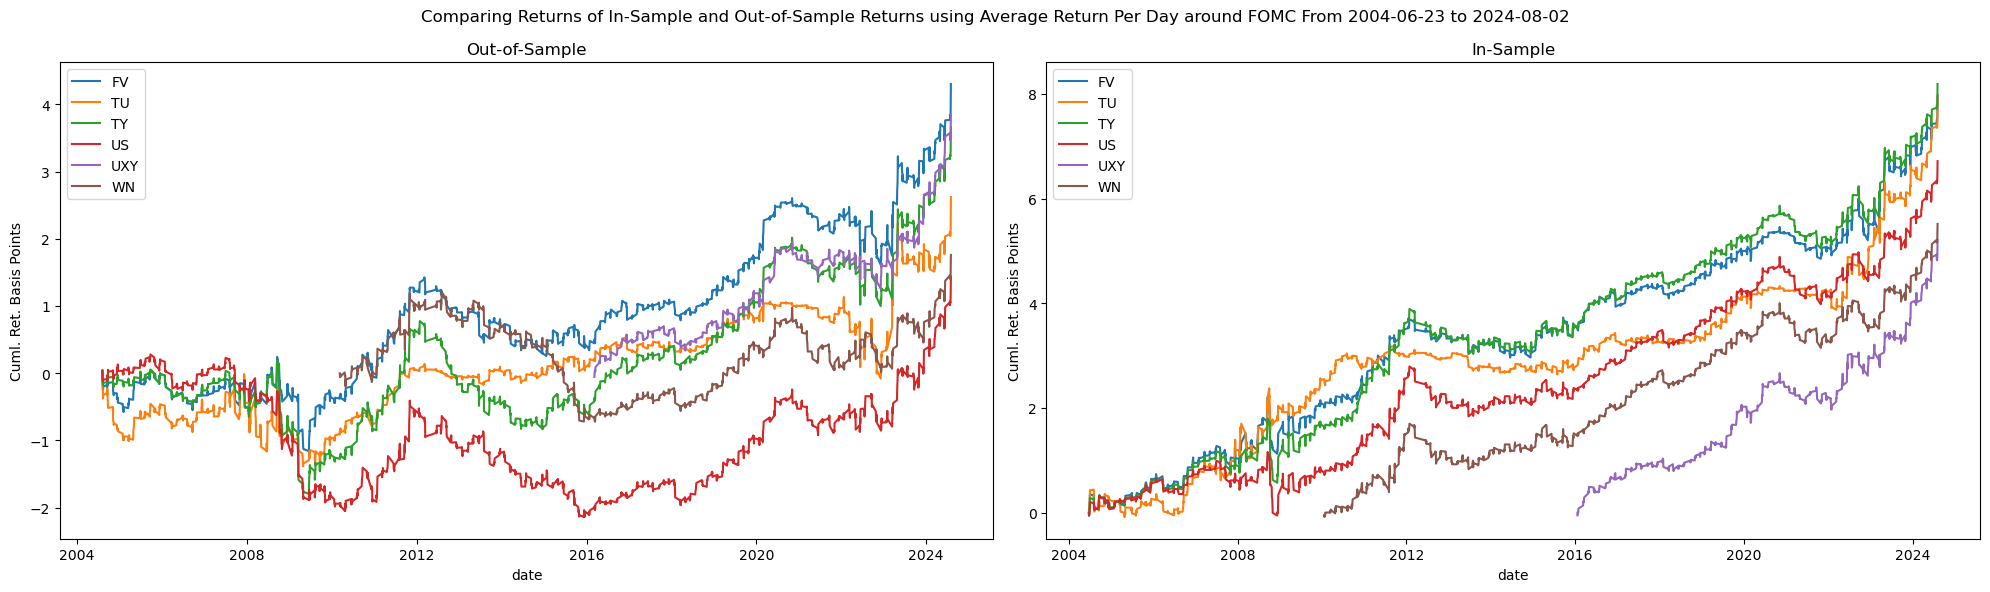

In [17]:
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

(df_oos.groupby([
    "date", "security"]).
    head(1).
    dropna().
    rename(columns = {"security": ""}).
    pivot(index = "date", columns = "", values = "signal_rtn").
    cumsum().
    plot(
        ax    = axes[0],
        title = "Out-of-Sample"))

(df_avg_signal.
    rename(columns = {"security": ""}).
    pivot(index = "date", columns = "", values = "signal_rtn").
    cumsum().
    plot(
        ax    = axes[1],
        title = "In-Sample"))

for ax in axes.flatten():
    ax.set_ylabel("Cuml. Ret. Basis Points")

fig.suptitle("Comparing Returns of In-Sample and Out-of-Sample Returns using Average Return Per Day around FOMC From {} to {}".format(
    df_oos.date.min(),
    df_oos.date.max()))

plt.tight_layout()

There is a substantial amount of sharpe lost going out-of-sample

In [18]:
(pd.concat([
    df_oos.assign(group = "oos"),
    df_avg_signal.assign(group = "is")])
    [["security", "group", "signal_rtn"]].
    groupby(["security", "group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"group": ""}).
    pivot(index = "security", columns = "", values = "signal_rtn").
    assign(sharpe_lost = lambda x: x["is"] - x["oos"]).
    apply(lambda x: np.round(x,3)).
    rename(columns = {
        "is"         : "In-Sample",
        "oos"        : "Out-of-Sample",
        "sharpe_lost": "Sharpe Lost"}))

,In-Sample,Out-of-Sample,Sharpe Lost
security,,,
FV,1.623,0.808,0.815
TU,1.606,0.491,1.115
TY,1.708,0.691,1.017
US,1.548,0.361,1.186
UXY,2.750,2.040,0.710
WN,1.799,0.559,1.240


# Conditioned Backtests

In this approach we are going to use the z-score of the nlp sentiment as a latent component. Then analyze the ex-post returns and then trade them.

In [19]:
processed_path = os.path.join(process_path, "ProcessedSentimentData.parquet")
df_zscore      = (pd.read_parquet(
    path = processed_path, engine = "pyarrow")
    [["date", "security", "lag_zscore"]])

In [59]:
df_event_group = (df_dates.query(
    "day == day.min()").
    merge(right = df_zscore, how = "inner", on = ["date"]).
    assign(group = lambda x: np.where(x.lag_zscore < 0, "neg_zscore", "pos_zscore"))
    [["event", "security", "group"]].
    rename(columns = {"security": "sentiment_ticker"}))

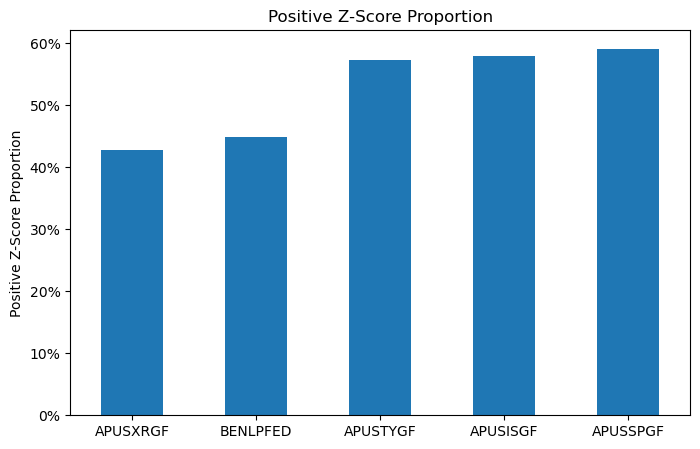

In [60]:
fig, axes = plt.subplots(figsize = (8,5))

(df_event_group.groupby(
    ["group", "sentiment_ticker"]).
    agg("count").
    reset_index().
    pivot(index = "sentiment_ticker", columns = "group", values = "event").
    assign(pos_ratio = lambda x: x.pos_zscore / x.sum(axis = 1))
    [["pos_ratio"]].
    sort_values("pos_ratio").
    plot(
        kind   = "bar",
        xlabel = "",
        legend = False,
        rot    = 0,
        ylabel = "Positive Z-Score Proportion",
        title  = "Positive Z-Score Proportion",
        ax     = axes))

axes.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))

In [61]:
df_group_prep = (df_tsy_prep.merge(
    right = df_dates, how = "inner", on = ["date"]).
    merge(right = df_event_group, how = "inner", on = ["event"]))

In [62]:
df_signal = (df_group_prep.drop(
    columns = ["date", "event"]).
    groupby(["security", "day", "sentiment_ticker", "group"]).
    agg("mean").
    reset_index().
    rename(columns = {"PX_bps": "signal"}))

In [63]:
df_namer = (pd.read_parquet(
    path = processed_path, engine = "pyarrow")
    [["plot_name", "security", "Description"]].
    drop_duplicates().
    rename(columns = {"security": "sentiment_ticker"}))

In [64]:
df_is_conditioned = (df_group_prep.merge(
    right = df_signal, how = "inner", on = ["sentiment_ticker", "group", "security", "day"]).
    assign(
        signal_rtn = lambda x: np.sign(x.signal) * x.PX_bps,
        group_var  = lambda x: x.group + " " + x.security))

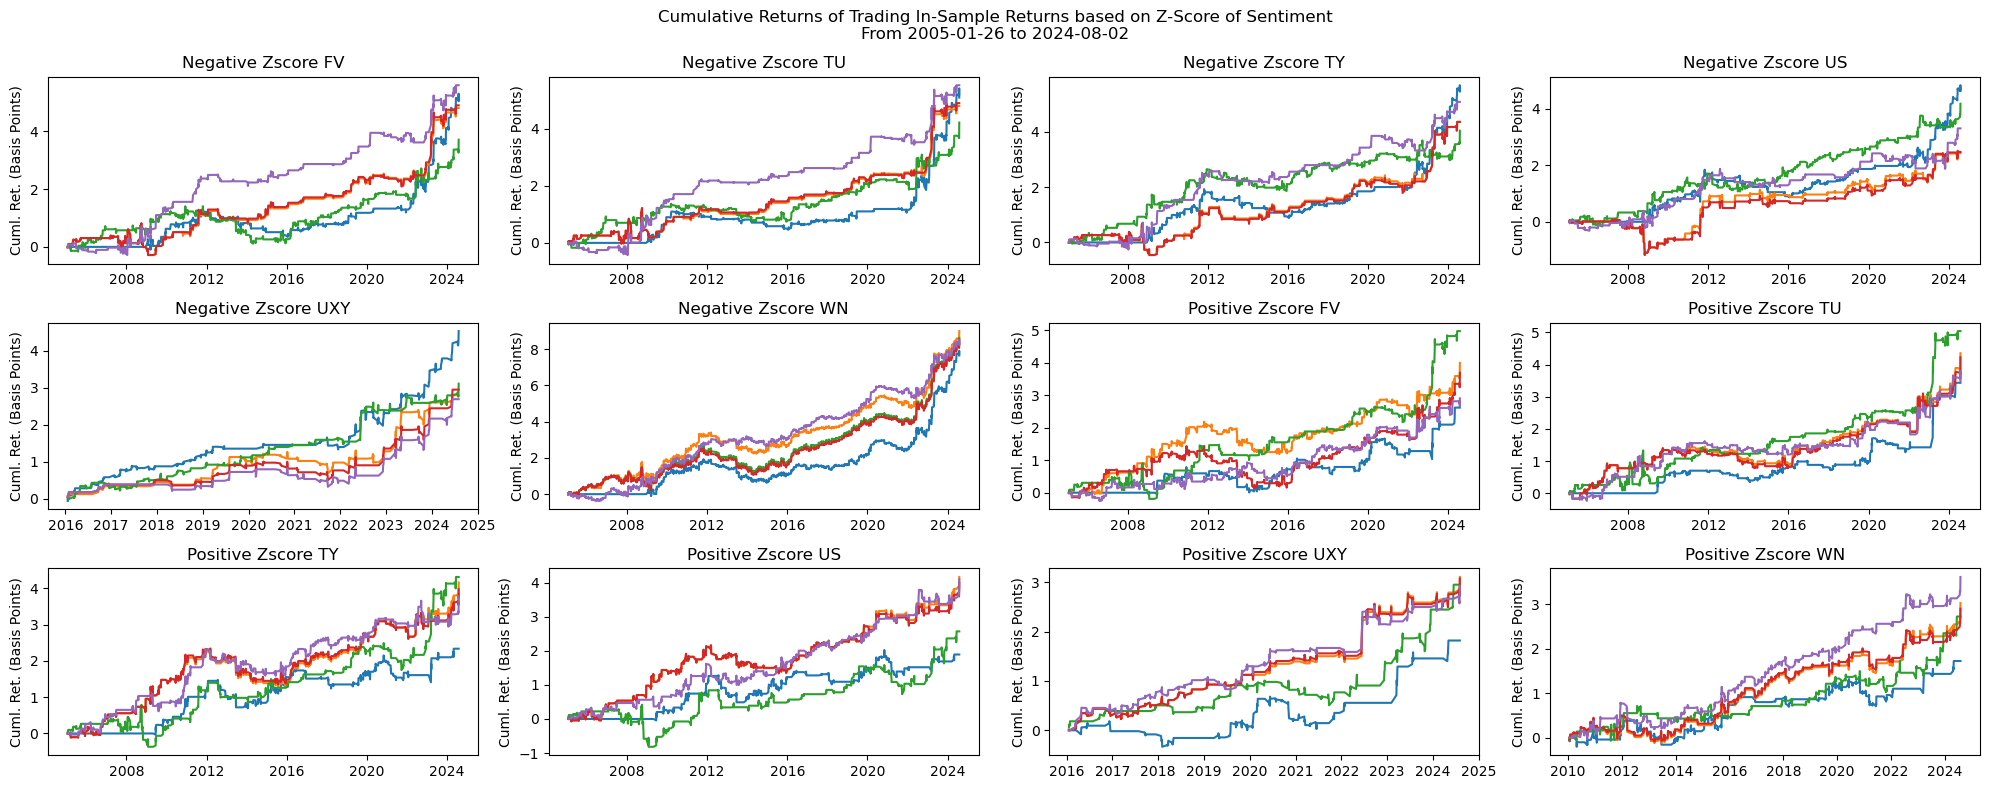

In [65]:
group_vars = df_is_conditioned.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars) // 3, nrows = len(group_vars) // 4, figsize = (20,8))

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_is_conditioned.query(
        "group_var == @group_var").
        groupby(["date", "sentiment_ticker"]).
        head(1).
        merge(right = df_namer, how = "inner", on = ["sentiment_ticker"]).
        rename(columns = {"plot_name": ""}).
        pivot(index = "date", columns = "", values = "signal_rtn").
        fillna(0).
        cumsum().
        plot(
            ax     = ax,
            legend = False,
            xlabel = "",
            ylabel = "Cuml. Ret. (Basis Points)",
            title  = (group_var.replace(
                "neg_zscore", "Negative Zscore").
                replace("pos_zscore", "Positive Zscore"))))

fig.suptitle("Cumulative Returns of Trading In-Sample Returns based on Z-Score of Sentiment\nFrom {} to {}".format(
    df_is_conditioned.date.min(),
    df_is_conditioned.date.max()))
plt.tight_layout()

In [66]:
(df_is_conditioned[
    ["security", "sentiment_ticker", "group", "signal_rtn"]].
    groupby(["security", "sentiment_ticker", "group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    pivot(index = ["security", "sentiment_ticker"], columns = "group", values = "signal_rtn").
    reset_index().
    merge(right = df_tmp_sharpe, how = "inner", on = ["security"]).
    merge(right = df_full_sharpe, how = "inner", on = ["security"]).
    melt(id_vars = ["security", "sentiment_ticker", "tmp_sharpe", "full_sharpe"]).
    merge(right = df_namer, how = "inner", on = ["sentiment_ticker"]).
    rename(columns = {
        "full_sharpe"     : "Full Sharpe",
        "tmp_sharpe"      : "FOMC Sharpe",
        "variable"        : "",
        "sentiment_ticker": "Sentiment Ticker",
        "security"        : "Security"}).
    replace({
        "neg_zscore": "Negative Z-Score",
        "pos_zscore": "Positive Z-Score"}).
    pivot(index = ["Security", "FOMC Sharpe", "Full Sharpe"], columns = ["", "Sentiment Ticker"], values = "value").
    reset_index().
    set_index("Security").
    apply(lambda x: np.round(x,3)))

FOMC Sharpe Full Sharpe Negative Z-Score                    \
Sentiment Ticker                                 APUSISGF APUSSPGF APUSTYGF   
Security                                                                      
FV                     0.775       0.304            2.368    2.201    2.054   
TU                     0.645       0.282            2.208    2.009    1.889   
TY                     0.701       0.279            2.213    2.058    1.951   
US                     0.574       0.166            1.584    1.395    1.314   
UXY                    0.519      -0.215            3.325    3.619    3.148   
WN                     0.540       0.045            1.956    2.319    2.030   

                                   Positive Z-Score                    \
Sentiment Ticker APUSXRGF BENLPFED         APUSISGF APUSSPGF APUSTYGF   
Security                                                                
FV                  1.383    2.183            1.223    1.347    1.521   
TU                  1.808    2.453            1.487    1.776    1.910   
TY                  1.449    2.351            1.432    1.419    1.556   
US                  1.670    2.201            1.681    1.609    1.751   
UXY                 2.999    3.943            2.725    2.884    3.136   
WN                  1.588    2.078            1.815    1.411    1.555   

                                    
Sentiment Ticker APUSXRGF BENLPFED  
Security                            
FV                  2.174    1.690  
TU                  2.019    2.511  
TY                  1.976    1.499  
US                  1.245    1.324  
UXY                 3.499    2.499  
WN                  2.069    1.281

Full Sample Sharpes

In [67]:
(df_is_conditioned.drop(
    columns = ["group_var"])
    [["security", "sentiment_ticker", "signal_rtn"]].
    groupby(["security", "sentiment_ticker"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    pivot(index = "security", columns = "sentiment_ticker", values = "signal_rtn").
    merge(right = df_tmp_sharpe, how = "inner", on = ["security"]).
    merge(right = df_full_sharpe, how = "inner", on = ["security"]).
    rename(columns = {
        "tmp_sharpe" : "FOMC Sharpe",
        "full_sharpe": "Full Sharpe"}))

,APUSISGF,APUSSPGF,APUSTYGF,APUSXRGF,BENLPFED,FOMC Sharpe,Full Sharpe
security,,,,,,,
FV,1.758748,1.723943,1.765565,1.743770,1.974765,0.775363,0.304486
TU,1.824195,1.860404,1.866263,1.888958,2.465876,0.645126,0.282134
TY,1.791693,1.694814,1.733870,1.684318,1.994807,0.700996,0.278826
US,1.626000,1.509229,1.541660,1.470582,1.834111,0.574146,0.166439
UXY,2.974167,3.198371,3.134001,3.219271,3.379170,0.518820,-0.215173
WN,1.868461,1.778968,1.758611,1.789275,1.729070,0.539936,0.044581


In [68]:
df_hit = (df_is_conditioned.assign(
    outcome = lambda x: np.where(x.signal_rtn > 0, "positive", "negative")))

In [69]:
(df_hit[
    ["security", "sentiment_ticker", "group", "outcome", "signal_rtn"]].
    groupby(["security", "sentiment_ticker", "group", "outcome"]).
    agg("count").
    reset_index().
    pivot(index = ["security", "sentiment_ticker", "group"], columns = "outcome", values = "signal_rtn").
    assign(hit_rate = lambda x: x.positive / x.sum(axis = 1)).
    reset_index().
    rename(columns = {
        "sentiment_ticker": "",
        "group"           : "Condition"}).
    replace({
        "neg_zscore": "Neg Z-Score",
        "pos_zscore": "Pos Z-Score"}).
    pivot(index = "security", columns = ["", "Condition"], values = "hit_rate").
    apply(lambda x: np.round(x,3)))

APUSISGF                APUSSPGF                APUSTYGF  \
Condition Neg Z-Score Pos Z-Score Neg Z-Score Pos Z-Score Neg Z-Score   
security                                                                
FV              0.528       0.545       0.552       0.539       0.550   
TU              0.502       0.515       0.527       0.521       0.524   
TY              0.536       0.557       0.537       0.552       0.537   
US              0.536       0.560       0.512       0.539       0.511   
UXY             0.544       0.580       0.565       0.588       0.582   
WN              0.550       0.572       0.593       0.553       0.589   

                         APUSXRGF                BENLPFED              
Condition Pos Z-Score Neg Z-Score Pos Z-Score Neg Z-Score Pos Z-Score  
security                                                               
FV              0.540       0.543       0.554       0.548       0.522  
TU              0.522       0.522       0.531       0.526       0.482  
TY              0.555       0.554       0.537       0.548       0.542  
US              0.540       0.556       0.544       0.548       0.547  
UXY             0.590       0.597       0.558       0.609       0.585  
WN              0.555       0.560       0.564       0.577       0.569

In [70]:
(df_hit[
    ["security", "sentiment_ticker", "outcome", "group_var"]].
    groupby(["security", "sentiment_ticker", "outcome"]).
    agg("count").
    reset_index().
    pivot(index = ["security", "sentiment_ticker"], columns = "outcome", values = "group_var").
    assign(hit_rate = lambda x: x.positive / x.sum(axis = 1)).
    reset_index().
    pivot(index = "security", columns = "sentiment_ticker", values = "hit_rate").
    apply(lambda x: np.round(x,3)))

sentiment_ticker,APUSISGF,APUSSPGF,APUSTYGF,APUSXRGF,BENLPFED
security,,,,,
FV,0.538,0.544,0.544,0.547,0.537
TU,0.509,0.524,0.523,0.526,0.507
TY,0.548,0.546,0.547,0.546,0.546
US,0.550,0.528,0.528,0.551,0.548
UXY,0.566,0.579,0.586,0.581,0.599
WN,0.564,0.568,0.569,0.561,0.573


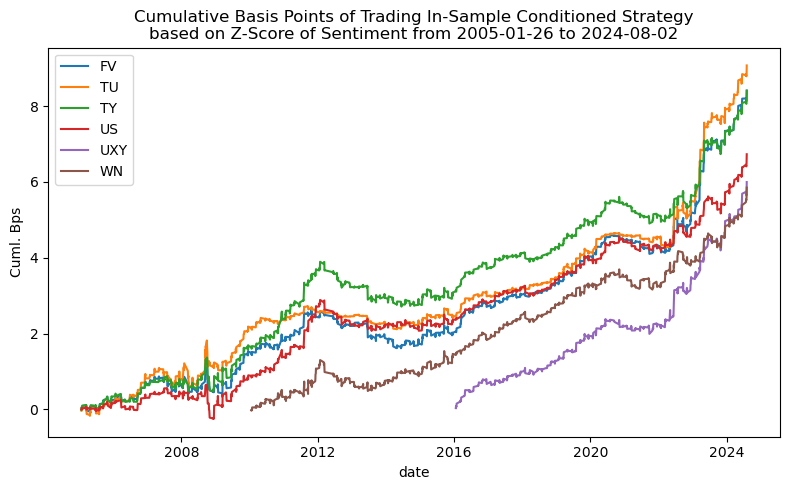

In [71]:
df_is_avg_rtn = (df_is_conditioned[
    ["date", "security", "signal_rtn"]].
    groupby(["date", "security"]).
    agg("mean").
    reset_index())
    
(df_is_avg_rtn.
    rename(columns = {"security": ""}).
    pivot(index = "date", columns = "", values = "signal_rtn").
    cumsum().
    plot(
        ylabel  = "Cuml. Bps",
        title   = "Cumulative Basis Points of Trading In-Sample Conditioned Strategy\nbased on Z-Score of Sentiment from {} to {}".format(
            df_is_conditioned.date.min(), 
            df_is_conditioned.date.max()),
        figsize = (8,5)))

plt.tight_layout()

In [72]:
(df_is_avg_rtn.drop(
    columns = ["date"]).
    groupby("security").
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    merge(right = df_tmp_sharpe, how = "inner", on = ["security"]).
    merge(right = df_full_sharpe, how = "inner", on = ["security"]).
    apply(lambda x: np.round(x,3)).
    rename(columns = {
        "signal_rtn" : "Avg. Port",
        "tmp_sharpe" : "FOMC Sharpe",
        "full_sharpe": "Full Sharpe"}))

,Avg. Port,FOMC Sharpe,Full Sharpe
security,,,
FV,2.050,0.775,0.304
TU,2.167,0.645,0.282
TY,1.996,0.701,0.279
US,1.958,0.574,0.166
UXY,3.617,0.519,-0.215
WN,2.102,0.540,0.045
